# T2R and leNuSTORM ring simulation

Generate the FLUKA files for the Pion Transfer line and LEnuSTORM Ring

Uses:
- essbeamsim.py 
- essbeamsim_plots.py
- essbeamsim.yaml

Needs:
Xsuite installation from : https://xsuite.readthedocs.io/en/latest/

In [2]:
import numpy as np
import pandas as pd

import xobjects as xo
import xtrack as xt

import math

import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.patches as patches


import re
import json
import yaml, pprint
# from dotdict import DotDict as dd


import essbeamsim as bsim
import essbeamsim_plots as bplot

import scipy
import scipy.constants

from particle import Particle

print(f' Beam parameters : ')
import os

%run ../InitPlots.py
    
MyPlots().configPlots('')

print_array_with_format = lambda x : ' '.join(f'{v:.5f}' for v in x)
distance2d = lambda x,y : np.sqrt((x[0]-y[0])**2 + (x[1]-y[1])**2)


 Beam parameters : 

>>> Running InitPlots.py - Version : 1.02 - 07.03.2023 (IE)
---- running configPlots function 


In [3]:
# Custom class to enable dot notation. Allows nested dicts

with open('essbeamsim.yaml','r') as fin:
    config = bsim.DotDict(yaml.safe_load(fin))
pprint.pprint(config)

{'beam_size': 0.1,
 'd2pivot_to_inj': [-2, 6.0],
 'h_decay_tunnel': 13,
 'h_ring_tunnel': 4,
 'h_tline_tunnel': 4,
 'l_decay_tunnel': 60,
 'mparking_radius': 10,
 'mparking_start': [0, 0, -101],
 'qaperture_x': 0.15,
 'qaperture_y': '0.15ß',
 'r_decay_pipe': 2.5,
 'ring_inj_x': -11.5,
 'ring_inj_z': 24.45,
 'ring_walls': 2,
 'ss_to_lemond': 50,
 't2r': {'l_bend_end': 0.35,
         'l_bend_woke': 0.5,
         'l_qfl_end': 0.2,
         'l_qfl_h': 0.9,
         'l_qfl_w': 0.9,
         'l_quad_end': 0.2,
         'l_quad_h': 0.6,
         'l_quad_w': 0.6,
         'l_vac': 0.1},
 'tlend_to_inj': [-2, 6.0],
 'trg_to_d1pivot': 2.5,
 'trg_to_lblnd': 310,
 'w_decay_tunnel': 15,
 'w_ring_tunnel': 2,
 'w_tline_tunnel': 4}


Reminder : relativistic mechanis formulae:

$\beta\gamma = P/\mathrm{m}_0$

$\gamma = 1/\sqrt{1-\beta^2}$

$\gamma = \sqrt{(\beta\gamma)^2+1}$

$\beta = \beta\gamma/\gamma$

## ESSnuSB Beam Parameters

$E = E_{kin} + E_0(=\mathrm{m}_0\, c^2)$

$E^2 = E_0^2 + P^2 \Rightarrow P^2 = \sqrt{E^2 - E_0^2} \Rightarrow P = \sqrt{(E-E_0)(E+E_0)}$

$P = \sqrt{E_{kin}(E_{kin}+2E_0)}$

$\beta\gamma = P/\mathrm{m}_0$

$\gamma = \sqrt{((\beta\gamma)^2+1}$

$\beta = \beta\gamma/\gamma$

In [4]:
pion = Particle.from_name('pi+')
muon = Particle.from_name('mu+')
proton = Particle.from_name('p')

# particle mass [MeV/c2] --> convert to [GeV/c2]
pmass_gev = proton.mass/1000
pimass_gev = pion.mass/1000
mumass_gev = muon.mass/1000

# print(xx.mass, xx.lifetime*1.0e-9)

# primary proton beam
pbeam_ekk_gev = 2.5
pbeam_etot = pbeam_ekk_gev + pmass_gev
pbeam_mom_gev = np.sqrt(pbeam_ekk_gev*(pbeam_ekk_gev+2*pmass_gev))
pbeam_beta, pbeam_gamma = bsim.particle_beta_gamma('p', pbeam_mom_gev)

# pion beam
beam_momentum = 0.7
pion_beta, pion_gamma = bsim.particle_beta_gamma('pi+', beam_momentum)
pion_decay_length = pion.lifetime*1.0e-9*scipy.constants.c*pion_gamma

# muon beam
muon_momentum = 0.4
muon_beta, muon_gamma = bsim.particle_beta_gamma('mu+', muon_momentum)
muon_lifetime = muon.lifetime*1.0e-9*muon_gamma  # lifetime is given in ns
muon_decay_length = muon_lifetime*scipy.constants.c

muon_momentum_max = 0.7
muon_beta_max, muon_gamma_max = bsim.particle_beta_gamma('mu+', muon_momentum_max)
muon_lifetime_max = muon.lifetime*1.0e-9*muon_gamma_max  # lifetime is given in ns
muon_decay_length_max = muon_lifetime_max*scipy.constants.c

print(f''' Paramters (units in GeV)
            primary proton beam:
                {pbeam_ekk_gev=}
                {pbeam_etot=:.5f}
                {pbeam_mom_gev=:.5f}
                {pbeam_gamma=:.5f}
                {pbeam_beta=:.5f}
            extracted pion beam:
                {beam_momentum=}
                {pion_gamma=:.5f} [s]
                {pion_decay_length=:.5f} [m]
            stored muon beam:
                {muon_momentum=}
                {muon_beta=:.5f}
                {muon_gamma=:.5f}
                {muon_lifetime=:.5f} [s], {muon_lifetime/1.0e-6:.5f} [us]
                {muon_decay_length=:.5f} [m]
                
                {muon_momentum_max=}
                {muon_beta_max=:.5f}
                {muon_gamma_max=:.5f}
                {muon_lifetime_max=:.5f} [s], {muon_lifetime_max/1.0e-6:.5f} [us]
                {muon_decay_length_max=:.5f} [m]
        ''')

 Paramters (units in GeV)
            primary proton beam:
                pbeam_ekk_gev=2.5
                pbeam_etot=3.43827
                pbeam_mom_gev=3.30777
                pbeam_gamma=3.66447
                pbeam_beta=0.96205
            extracted pion beam:
                beam_momentum=0.7
                pion_gamma=5.11411 [s]
                pion_decay_length=39.91268 [m]
            stored muon beam:
                muon_momentum=0.4
                muon_beta=0.96684
                muon_gamma=3.91563
                muon_lifetime=0.00001 [s], 8.60257 [us]
                muon_decay_length=2578.98569 [m]
                
                muon_momentum_max=0.7
                muon_beta_max=0.98880
                muon_gamma_max=6.70017
                muon_lifetime_max=0.00001 [s], 14.72015 [us]
                muon_decay_length_max=4412.98966 [m]
        


## Load the LEnuSTORM Lattice

In [7]:
# --- save LEnuSTORM ring info to a parquet file
gen_lenustorm = False
if gen_lenustorm:
    FULL_RING, tw_df, survey_df, lenustorm_df = bsim.generate_lenustorm(muon_momentum, icycle=964, verbose=True)
    selected_columns = lenustorm_df.columns.to_list()
    selected_columns.remove('element')
    # print(selected_columns)
    lenustorm_df[selected_columns].to_parquet(f'lenustorm.parquet')
    print(f'--- lenustormdf saved to lenustorm.parquet')
else:
    lenustorm_df = pd.read_parquet('lenustorm.parquet')
    
lenustorm_df.head()


,s_fr,element_type,name_fr,isthick,isreplica,parent_name,iscollective,X,Y,Z,...,tilt,X_cm,Y_cm,Z_cm,theta_deg,el_name,model_id,model_name,ishalf,Consecutive_Count
0,0.000000,Drift,D_stoA1,True,False,None,False,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,D_stoA1.0,None,None,False,1
1,0.994410,Quadrupole,QDS_to_A2,True,False,None,False,0.0,0.0,0.994410,...,0.0,0.0,0.0,99.440964,0.0,QDS2A2.0,QDS_to_A2,qdsa2vol,False,1
2,1.244410,Drift,D_stoA1,True,False,None,False,0.0,0.0,1.244410,...,0.0,0.0,0.0,124.440964,0.0,D_stoA1.1,None,None,False,1
3,2.238819,Quadrupole,QFS_to_A1,True,False,None,False,0.0,0.0,2.238819,...,0.0,0.0,0.0,223.881929,0.0,QFS2A1.0,QFS_to_A1,qfsa1vol,False,1
4,2.488819,Drift,D_stoA1,True,False,None,False,0.0,0.0,2.488819,...,0.0,0.0,0.0,248.881929,0.0,D_stoA1.2,None,None,False,1


In [9]:
if 0 :
    FULL_RING.survey().plot()

## Load the transfer line

In [14]:
# fin = '/Users/iliasefthymiopoulos/cernbox/Projects/ESS_NuBeam/From_Max/ESSnuSB_transline.ESSnuSB_dogleg'
# fin = '/Users/iliasefthymiopoulos/cernbox/Projects/ESS_NuBeam/From_Max/20241212-line-triplet.json'
# fin = '/Users/iliasefthymiopoulos/cernbox/Projects/ESS_NuBeam/From_Max/20241213-thicklensline.json'
# fin = './20241213-thicklensline.json'
fin = '/Users/iliasefthymiopoulos/cernbox/Projects/ESS_NuBeam/From_Max/20250807-transfer-line-1050.20250807-transfer-line-1050'

TRANSLINE, t2r_df, srv_df, tlcomplete_df = bsim.gen_t2rline(fin)

ttcols2use = ['s_tl','element_type','name_tl','name_srv','el_name','model_id', 'model_name', 'ishalf', 'Consecutive_Count']
tlcomplete_df[ttcols2use]

Loading line from dict:   0%|          | 0/892 [00:00<?, ?it/s]

Done loading line from dict.           


AttributeError: 'DataFrame' object has no attribute 'element_type'

In [ ]:
TRANSLINE = xt.Line.from_json(fin)


Loading line from dict:   0%|          | 0/892 [00:00<?, ?it/s]

Done loading line from dict.           


In [19]:
_dfy = TRANSLINE.to_pandas()
_dfysrv = TRANSLINE.survey().to_pandas()
display(_dfy.head())
display(_dfysrv.head())

,s,element_type,name,isthick,isreplica,parent_name,iscollective,element,s_start,s_center,s_end
0,0.0,Bend,mbtl0.0,True,False,None,False,"Bend(length=1.5, k0=0.286, k1=0, h=0.286, k0_f...",0.0,0.75,1.5
1,1.5,Drift,drift_4,True,False,None,False,Drift(length=0.5),1.5,1.75,2.0
2,2.0,Quadrupole,mq_t2r.0,True,False,None,False,"Quadrupole(k1=-1, k1s=0, length=0.8, num_multi...",2.0,2.40,2.8
3,2.8,Drift,drift_5,True,False,None,False,Drift(length=0.5),2.8,3.05,3.3
4,3.3,Quadrupole,mq_t2r.1,True,False,None,False,"Quadrupole(k1=1.49, k1s=0, length=0.8, num_mul...",3.3,3.70,4.1


,X,Y,Z,theta,phi,psi,name,s,length,isthick,drift_length,angle,tilt,element_type
0,0.000000,0.0,0.000000,0.00000,0.0,0.0,mbtl0.0,0.0,1.5,True,1.5,0.42828,0.0,Bend
1,-0.316330,0.0,1.454563,-0.42828,0.0,0.0,drift_4,1.5,0.5,True,0.5,0.00000,0.0,Drift
2,-0.523984,0.0,1.909403,-0.42828,0.0,0.0,mq_t2r.0,2.0,0.8,True,0.8,0.00000,0.0,Quadrupole
3,-0.856229,0.0,2.637148,-0.42828,0.0,0.0,drift_5,2.8,0.5,True,0.5,0.00000,0.0,Drift
4,-1.063883,0.0,3.091989,-0.42828,0.0,0.0,mq_t2r.1,3.3,0.8,True,0.8,0.00000,0.0,Quadrupole


In [20]:
_dfy.merge(_dfysrv, left_index=True, right_index=True, suffixes=('_tl', '_srv'))

,s_tl,element_type_tl,name_tl,isthick_tl,isreplica,parent_name,iscollective,element,s_start,s_center,...,phi,psi,name_srv,s_srv,length,isthick_srv,drift_length,angle,tilt,element_type_srv
0,0.000000,Bend,mbtl0.0,True,False,None,False,"Bend(length=1.5, k0=0.286, k1=0, h=0.286, k0_f...",0.000000,0.750000,...,0.0,0.0,mbtl0.0,0.000000,1.500000,True,1.500000,0.428280,0.0,Bend
1,1.500000,Drift,drift_4,True,False,None,False,Drift(length=0.5),1.500000,1.750000,...,0.0,0.0,drift_4,1.500000,0.500000,True,0.500000,0.000000,0.0,Drift
2,2.000000,Quadrupole,mq_t2r.0,True,False,None,False,"Quadrupole(k1=-1, k1s=0, length=0.8, num_multi...",2.000000,2.400000,...,0.0,0.0,mq_t2r.0,2.000000,0.800000,True,0.800000,0.000000,0.0,Quadrupole
3,2.800000,Drift,drift_5,True,False,None,False,Drift(length=0.5),2.800000,3.050000,...,0.0,0.0,drift_5,2.800000,0.500000,True,0.500000,0.000000,0.0,Drift
4,3.300000,Quadrupole,mq_t2r.1,True,False,None,False,"Quadrupole(k1=1.49, k1s=0, length=0.8, num_mul...",3.300000,3.700000,...,0.0,0.0,mq_t2r.1,3.300000,0.800000,True,0.800000,0.000000,0.0,Quadrupole
5,4.100000,Drift,drift_6,True,False,None,False,Drift(length=0.5),4.100000,4.350000,...,0.0,0.0,drift_6,4.100000,0.500000,True,0.500000,0.000000,0.0,Drift
6,4.600000,Quadrupole,mq_t2r.2,True,False,None,False,"Quadrupole(k1=-1, k1s=0, length=0.8, num_multi...",4.600000,5.000000,...,0.0,0.0,mq_t2r.2,4.600000,0.800000,True,0.800000,0.000000,0.0,Quadrupole
7,5.400000,Drift,drift_7,True,False,None,False,Drift(length=0.5),5.400000,5.650000,...,0.0,0.0,drift_7,5.400000,0.500000,True,0.500000,0.000000,0.0,Drift
8,5.900000,Bend,mbtl0.1,True,False,None,False,"Bend(length=1.5, k0=0.286, k1=0, h=0.286, k0_f...",5.900000,6.650000,...,0.0,0.0,mbtl0.1,5.900000,1.500000,True,1.500000,0.428280,0.0,Bend
9,7.400000,Drift,drift_13,True,False,None,False,Drift(length=0.739),7.400000,7.769714,...,0.0,0.0,drift_13,7.400000,0.739428,True,0.739428,0.000000,0.0,Drift


## Build FLUKA Geometry

Model parking area
x = -500 +500     Dx = 10 m
z = -20000 -5000 Dz = 150 m

Injection point to LEnuSTORM ring
x = -10 m from target
z =  15 m from target
angle = to point to a ND module at 250m from the target.

### Plot line and layout

work in [z, x] coordinates

In [21]:
do_plot = True

In [22]:
# -- calculate overall angle of LEnuSTORM ring

injection_point = [config.ring_inj_z, config.ring_inj_x] #
lblnd_point = [config.trg_to_lblnd, 0]

ring_angle, ring_c =  bsim.line_equation(injection_point, lblnd_point)
ring_angle_deg = ring_angle*180/np.pi

dist = bsim.distance_point_to_line(injection_point, lblnd_point, [config.l_decay_tunnel, -config.w_decay_tunnel/2])
print(f' === Parameters for the LEnuSTORM ring ====')
print(f' -  target to ND distance ...................[m] {config.trg_to_lblnd}')
print(f' -  LEnuSTORM injection point to target .....[m] x={injection_point[1]} z={injection_point[0]}')
print(f'              angle ......................... {ring_angle:.5f} [rad] {ring_angle_deg:.3f} [deg]')
print(f' - Distance to edge of the decay tunnel .....[m] {dist/100:.5f} ')

 === Parameters for the LEnuSTORM ring ====
 -  target to ND distance ...................[m] 310
 -  LEnuSTORM injection point to target .....[m] x=-11.5 z=24.45
              angle ......................... 0.04027 [rad] 2.307 [deg]
 - Distance to edge of the decay tunnel .....[m] 0.02566 


In [26]:
# TRANSLINE.element_dict

In [24]:
# --- update config parameters

config.ring_angle = ring_angle
config.ring_angle_deg = ring_angle_deg
config.ring_to_decaytunnel = dist

bend_0 = TRANSLINE.element_dict['bend_0']
_angle = bend_0.k0 * bend_0.length

d1dipole = DotDict()
d1dipole.arc_length = bend_0.length
d1dipole.angle      = bend_0.k0 * bend_0.length
d1dipole.angle_deg  = d1dipole.angle * 180/np.pi
d1dipole.radius     = 1/bend_0.k0
d1dipole.length     = bend_0.length/d1dipole.angle * np.sin(d1dipole.angle)
d1dipole.deflection = np.atan(d1dipole.angle/2) * d1dipole.length
d1dipole.aperture   = [(d1dipole.deflection + config.beam_size)*1.2,
                       config.beam_size * 1.2]
d1dipole.pivot  = d1dipole.radius * np.sin(d1dipole.angle/2)
config.d1dipole = d1dipole

tl2r = config.t2r
tl2r.d1dipole   = d1dipole
tl2r.start      = [0, config.trg_to_d1pivot - d1dipole.pivot]
tl2r.d1pivot    = [0, config.trg_to_d1pivot]
tl2r.d2pivot    = [tlcomplete_df.iloc[-1].X, tlcomplete_df.iloc[-1].Z - d1dipole.pivot]
tl2r.injection  = np.add(tl2r.d2pivot, config.d2pivot_to_inj)
tl2r.segments   = [distance2d([0, 0], tl2r.d1pivot),
                   distance2d(tl2r.d1pivot, tl2r.d2pivot),
                   distance2d(tl2r.d2pivot, tl2r.injection)]
tl2r.slength    =  tl2r.start[1] + tlcomplete_df.iloc[-1].s_tl + np.linalg.norm(config.tlend_to_inj)
tl2r.length     = np.sum(tl2r.segments)

_tt_tunnel_x = np.array([tl2r.d1pivot[0]+config.w_tline_tunnel/2, 
                         tl2r.d1pivot[0]+config.w_tline_tunnel/2,
                         -tl2r.d1pivot[0]+config.w_tline_tunnel/2,
                         -tl2r.d1pivot[0]+config.w_tline_tunnel/2])
_tt_tunnel_z = np.array([tl2r.d1pivot[1],
                         tl2r.d1pivot[1]+tl2r.length,
                         tl2r.d1pivot[1]+tl2r.length,
                         tl2r.d1pivot[1]])

_tt_coord_transform = bsim.create_transform(tl2r.d1pivot[1], tl2r.d1pivot[0], -d1dipole.angle)
config.t2r_tunnel_coord = bsim.apply_transform(_tt_coord_transform, np.array([_tt_tunnel_z, _tt_tunnel_x]))

print(f'--- Config parameters updated:')
pprint.pprint(config)

KeyError: 'bend_0'

In [ ]:
# if I ever need to produce a nice printout
if 0 : 

    print(f' === T2R Line Parameters:')
    print(f'    starting coordinates (x, z)... [m]  {tt_start_x:.5f}, {tt_start_z:.5f}')
    print(f'    D1 pivot coordinates (x, z)... [m]  {tt_d1_pivot}')
    print(f'    D2 pivot coordinates (x, z)... [m]  {print_array_with_format(tt_d2_pivot)}')
    print(f'    injection coordinates (x, z).. [cm]  {print_array_with_format(tt_inj_point)}')

    print(f'    D1 iron length ............... [m]  {tt_bend_length:.3f}')
    print(f'    bending angle ................ [deg] {tt_bend_angle_deg:.3f}')
    print(f'    deflection  in D1 ............ [m]  {tt_bend_deflection:.3f}')
    print(f'    D1 aperture (x, y)............ [m]   {print_array_with_format(tt_bend_aperture)}')
    print(f'    TT line segments ............. [m]   {print_array_with_format(tt_segments)}')
    print(f'    TT line length up to D2 ...... [m]   {tt_length:.3f}')
    print(f'    MAD-X TT line length s ....... [m]   {TRANSLINE.get_length():.3f}')
    print(f'    Total T2R length ............. [m]   {tt_slength:.3f}')
    print(f'    Pion 0.7GeV decay distance ... [m]   {pion_decay_length:.3f}')
    print(f'    TT line in decays ............    {TRANSLINE.get_length()/pion_decay_length:.3f}')

    print('')
    print(f' === LEnuSTORM ring Parameters:')
    print(f'    target to LBL-ND distance ..............[m] {bsim_parameters["trg_to_lblnd"]}')
    print(f'    LEnuSTORM angle ........................    {lenustorm_angle:.5f} [rad] {lenustorm_angle_deg:.3f} [deg]')
    print(f'    distance to edge of the decay tunnel ...[m] {lenustorm_to_decay_tunnel:.5f} ')


### LEnuSTORM ring geometry


In [23]:
ring_coord_transform = bsim.create_transform(tt_inj_point[1]*100, tt_inj_point[0]*100, lenustorm_angle)
print(ring_coord_transform)

ring_2d = lenustorm_df[['Z_cm','X_cm']].to_numpy()
transformed = bsim.apply_transform(ring_coord_transform, np.array(ring_2d).T)
lenustorm_df['Z_wc'] = transformed[0]
lenustorm_df['X_wc'] = transformed[1]


# --- Ring tunnel
_wout = bsim_parameters['w_ring_tunnel'] + config['ring_walls']
oring_tunnel_x = np.array([_wout, 
                           _wout, 
                           lenustorm_df.X.min()-_wout, 
                           lenustorm_df.X.min()-_wout, 
                           _wout])*100
_zup = 5 # upstream margin for ring tunnel
oring_tunnel_z = np.array([lenustorm_df.Z.min()-_wout-_zup, 
                           lenustorm_df.Z.max()+_wout, 
                           lenustorm_df.Z.max()+_wout, 
                           lenustorm_df.Z.min()-_wout-_zup, 
                           lenustorm_df.Z.min()-_wout-_zup])*100
config['ring_tunnel_out_coord'] = bsim.apply_transform(ring_coord_transform, np.array([oring_tunnel_z, oring_tunnel_x]))

_wout = config['w_ring_tunnel']
iring_tunnel_x = np.array([_wout, 
                           _wout, 
                           lenustorm_df.X.min()-_wout, 
                           lenustorm_df.X.min()-_wout, 
                           _wout])*100
iring_tunnel_z = np.array([lenustorm_df.Z.min()-_wout-_zup, 
                           lenustorm_df.Z.max()+_wout, 
                           lenustorm_df.Z.max()+_wout, 
                           lenustorm_df.Z.min()-_wout-_zup, 
                           lenustorm_df.Z.min()-_wout-_zup])*100
config['ring_tunnel_in_coord'] = bsim.apply_transform(ring_coord_transform, np.array([iring_tunnel_z, iring_tunnel_x]))



NameError: name 'tt_inj_point' is not defined

In [23]:
bsim_parameters

{'trg_to_lblnd': 310,
 'ss_to_lemond': 50,
 'l_decay_tunnel': 60,
 'w_decay_tunnel': 15.0,
 'r_decay_pipe': 2.5,
 'h_decay_tunnel': 13.0,
 'w_ring_tunnel': 2,
 'h_ring_tunnel': 4,
 'ring_walls': 2,
 'w_tline_tunnel': 4,
 'h_tline_tunnel': 4,
 'mparking_start': [0, 0, -101],
 'mparking_radius': 10,
 'l_bend': 2.0,
 'l_bend_end': 0.35,
 'l_bend_woke': 0.5,
 'l_quad': 0.8,
 'l_quad_end': 0.2,
 'l_quad_w': 0.6,
 'l_quad_h': 0.6,
 'l_qfl': 0.8,
 'l_qfl_end': 0.2,
 'l_qfl_w': 0.9,
 'l_qfl_h': 0.9,
 'l_vac': 0.1,
 'trg_to_d1pivot': 2.5,
 'd2pivot_to_inj': (-2, 6.0),
 'tlend_to_inj': (-2, 6.0),
 'beam_size': 0.2,
 'qaperture_x': 0.15,
 'qaperture_y': 0.15,
 'ring_angle': 0.04022454115850677,
 'ring_angle_deg': 2.3046964412327093,
 'tl_tunnel_coord': array([[  566.10234156,  2923.46635877,  2923.46635877,   566.10234156],
        [   50.78690439, -1284.70188783, -1284.70188783,    50.78690439]]),
 'ring_tunnel_out_coord': array([[ 1006.9806398 , 14243.8826386 , 14314.34066119,  1077.43866239,
 

In [13]:
def plot_trline(df, params):
        
    fig, ax = plt.subplots(figsize=(15,10))

    for el in df.itertuples():
        _name = el.name_tl
        _type = el.element_type
        if _type == 'Bend':
            _length = df.drift_length
            _length_tot = _length + 2*params['l_bend_end']
            _width = df.d1dipole['width']
            _edgecolor = 'blue'
            _facecolor = 'lightblue'
        elif _type == 'Quadrupole' :
            if _name in ['QFL1', 'QFL2']: 
                _length = df.l_qfl
                _length_tot = df.l_qfl_tot
                _width = df.l_qfl_w
                _edgecolor = 'magenta'
                _facecolor = 'yellow'
            else:
                _length = df.l_quad
                _length_tot = df.l_quad_tot
                _width = df.l_quad_w
                _edgecolor = 'orange'
                _facecolor = 'green'
        elif _type == 'Marker':
            if _name == 'TARGET':
                _length = 0.78
                _length_tot = _length
                _width = 0.02
                _edgecolor = 'black'
                _facecolor = 'grey'
            else:
                _length = 0.10
                _length_tot = _length
                _width = 0.10
                _edgecolor = 'black'
                _facecolor = 'grey'
        
        print(f" -- {_name} : xy ={el.coord[1]:.3f}, {el.coord[0]}  {el.angle}")
        _center = (el.coord[1], el.coord[0])

        bottom_left = bsim.compute_corner_from_center(_center, _length_tot, _width, el.angle)
        # print(f'\t --- {bottom_left=}')
        ax.add_patch(
            patches.Rectangle(
                xy=bottom_left, width=_length_tot, height=_width, angle=el.angle*180/np.pi,
                edgecolor='lightgrey', facecolor='brown', linewidth=1, linestyle='--'
            )
        )
        bottom_left = bsim.compute_corner_from_center(_center, _length, _width, el.angle)
        # print(f'\t --- {bottom_left=}')
        ax.add_patch(
            patches.Rectangle(
                xy=bottom_left, width=_length, height=_width, angle=el.angle*180/np.pi,
                edgecolor=_edgecolor, facecolor=_facecolor, linewidth=1
            )
        )
        
        ax.plot(*_center, "ro")  # Center marked as a red dot

    pxx, pzz = df.get_points()
    
    pxx.insert(len(pxx)-1, pxx[len(pxx)-2])
    pzz.insert(len(pzz)-1, 0.5*(pzz[-2]+pzz[-1]))
    ax.plot(pzz[:-1], pxx[:-1], '*-', linewidth=0.7, color='green')
    ax.plot(pzz[-2:], pxx[-2:], '*--', linewidth=0.7, color='olive')

    # ax.set_xlim(0, 18)
    # ax.set_ylim(0, 5)
    ax.set_aspect('equal')

    ax.set_title(df.__getattribute__('method'))
    # Show the plot
    ax.grid(which='major', color='k', linestyle='-', alpha=0.5)
    ax.grid(which='minor', color='r', linestyle='--', alpha=0.2)
    # ax.grid('minor', color='g', linestyle='--')
    ax.minorticks_on()
    plt.show()
    return fig

def plot_layout(tlpoints, ringdf, layout_params):

    fig, ax = plt.subplots(figsize=(20, 10))

    # --- plot infrastructure
    
    x_width = layout_params['w_decay_tunnel']/2*100
    r_decay = layout_params['r_decay_pipe']*100
    z_length = layout_params['l_decay_tunnel']*100
    z_dump = (z_length - 1000)
    
    
    xtunnel = [0, -x_width, -x_width, x_width, x_width, 0]
    rdecay = [0, -r_decay, -r_decay, r_decay, r_decay, 0]
    ztunnel = [0, 0, z_length, z_length, 0, 0]
    zpipe = [0, 0, z_dump, z_dump, 0, 0]

    # plt.plot(ztunnel, xtunnel, 'o-', color='black')
    ax.fill(ztunnel, xtunnel, color='brown')
    ax.fill(zpipe, rdecay, color='cyan')
    ax.plot(layout_params['trg_to_lblnd']*100, 0, 'X', ms=15, color='red', label='LBLND')

    to_lblnd = (layout_params['trg_to_lblnd']+20)*100
    ax.arrow(0, 0, to_lblnd, 0, shape='full', linewidth=2, linestyle='--', 
             length_includes_head=True, head_width=0.5, head_length=8, color='blue', label=None)
    
    xx1 = [float(item[0]) for item in tlpoints]
    zz1 = [float(item[1]) for item in tlpoints]
    ax.plot(np.array(zz1)*100, np.array(xx1)*100, '*-', color='red', label='T2R')
    
    _inj_point = tlpoints[-1]
    _angle = config['ring_angle']
    
    ring_coord_transform = ttline.create_transform(_inj_point[1]*100, _inj_point[0]*100, _angle)
    print(ring_coord_transform)

    ring_2d = ringdf[['Z_cm','X_cm']].to_numpy()
    transformed = ttline.apply_transform(ring_coord_transform, np.array(ring_2d).T)
    ringdf['Z_wc'] = transformed[0]
    ringdf['X_wc'] = transformed[1]

    ring_tunnel_x = np.array([2, 2, ringdf.X.min()-2, ringdf.X.min()-2, 2])*100
    ring_tunnel_z = np.array([ringdf.Z.min()-2, ringdf.Z.max()+2, ringdf.Z.max()+2, ringdf.Z.min()-2, ringdf.Z.min()-2])*100
    ring_tunnel_transformed = ttline.apply_transform(ring_coord_transform, np.array([ring_tunnel_z, ring_tunnel_x]))
    print(ring_tunnel_transformed[0], ring_tunnel_transformed[1])
    # ax.plot(ring_tunnel_transformed[0], ring_tunnel_transformed[1], '*-', color='magenta', label=None)
    ax.fill(ring_tunnel_transformed[0], ring_tunnel_transformed[1], color='moccasin', label=None)

    # ringdf.plot('Z_cm','X_cm', ax=ax)
    # ax.plot(ringdf.iloc[0].Z_cm, ringdf.iloc[0].X_cm, '*', color='red')

    ringdf.plot('Z_wc', 'X_wc', ax=ax, label='LEnuSTORM')
    ax.plot(ringdf.iloc[0].Z_wc, ringdf.iloc[0].X_wc, '*', color='green', label=None)
    
    _endss = ringdf[ringdf.theta == 0].iloc[-1]
    print('-- end of SS:',_endss.Z_wc, _endss.X_wc, layout_params['trg_to_lblnd']*100)
    ax.plot([_endss.Z_wc, layout_params['trg_to_lblnd']*100], [_endss.X_wc, 0], linestyle='--', lw=1, color='green', label=None)
    
    # --- place LEMOND detector
    def place_lemond(ax, ay, bx, by, l):
        ''' return point coordinates at distance l from line (AB)'''
        dx = bx - ax
        dy = by - ay
        ab_length = np.sqrt(dx**2 + dy**2)
        if ab_length == 0:
            raise ValueError("points A and B cannot be the same!")
        udx = dx/ab_length
        udy = dy/ab_length
        cx = ax + l * udx
        cy = ay + l * udy
        return cx, cy
    
    lemond_z, lemond_x = place_lemond(_endss.Z_wc, _endss.X_wc, layout_params['trg_to_lblnd']*100, 0, layout_params['ss_to_lemond']*100)
    print(' --- LEMOND : ', lemond_z, lemond_x)
    ax.plot(lemond_z, lemond_x, 'X', color='brown', ms=15, label='LEMOND')

    ax.fill(bsim_parameters['ring_tunnel_out_coord'][0], bsim_parameters['ring_tunnel_out_coord'][1], '-', color='brown')
    ax.fill(bsim_parameters['ring_tunnel_in_coord'][0], bsim_parameters['ring_tunnel_in_coord'][1], '-', color='orange')

    ax.set_title('ESSnuSB+ : Pion Transfer Line and LEnuSTORM ring layout')
    # plt.title(f'LEnuSTORM ring ($z_{{inj}}$ = {lenustorm_inj_z} [cm], $x_{{inj}}$ = {lenustorm_inj_x} [cm])')
    # ax.plot(transformed[0], transformed[1])
    # ax.plot(transformed[0][0], transformed[1][0], '+', color='green')
    ax.axis('equal')
    ax.grid(which='major', color='r', linestyle='-', alpha=0.5)
    ax.grid(which='minor', color='r', linestyle='--', alpha=0.2)
    ax.minorticks_on()
    ax.legend()
    
    return fig


In [22]:
tlcomplete_df.iloc[3]

s_tl                                                              0.35
element_type                                                      Bend
name_tl                                                         bend_0
isthick                                                           True
isreplica                                                        False
parent_name                                                       None
iscollective                                                     False
element              Bend(length=1.2, k0=0.428, k1=0, h=0.428, mode...
k0                                                            0.428275
k1                                                                 NaN
X                                                                  0.0
Y                                                                  0.0
Z                                                                 0.35
theta                                                              0.0
phi   

 -- _horn_end_plane : xy =0.000, 0.0  0.0
 -- drift_1 : xy =0.000, 0.0  0.0
 -- _upstream_end : xy =0.000, 35.0  0.0


AttributeError: 'DataFrame' object has no attribute 'd1dipole'

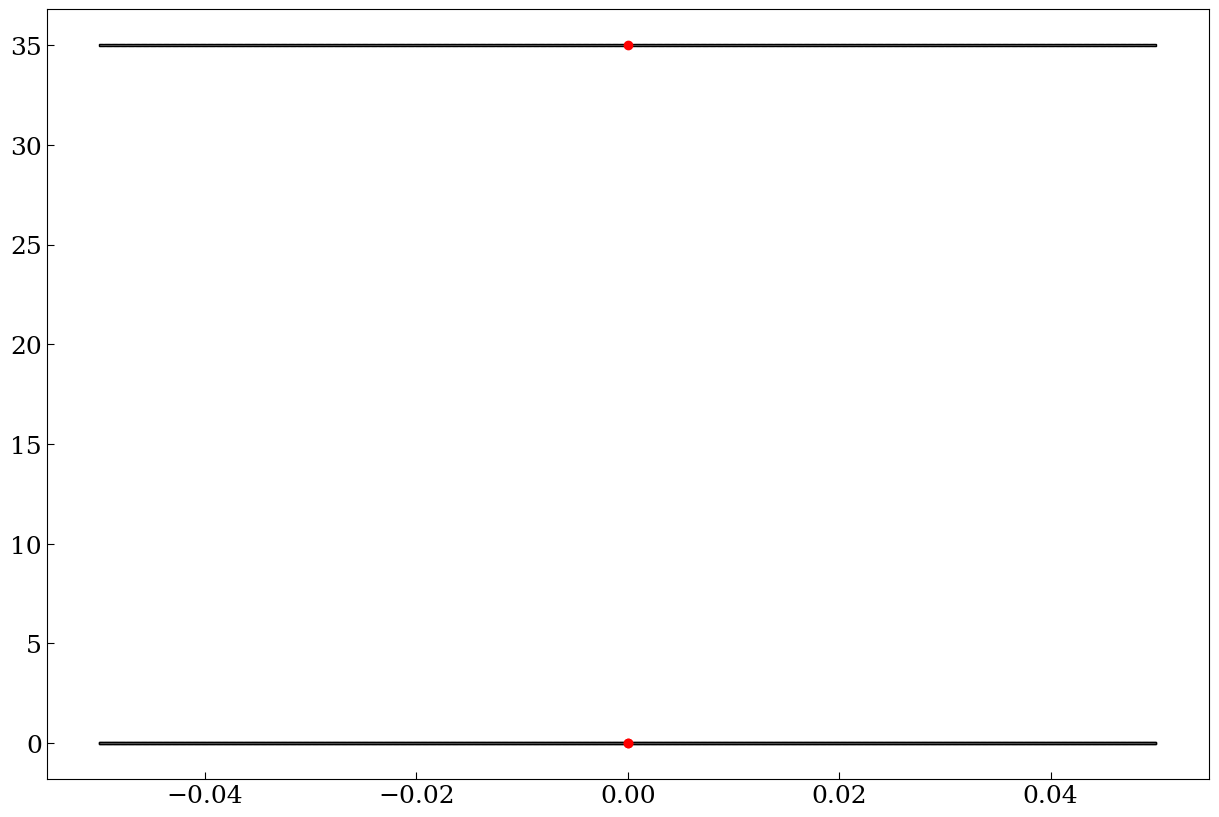

In [15]:
if do_plot:
    _tlcomplete_df = tlcomplete_df.copy()
    _tlcomplete_df['coord'] = _tlcomplete_df[['Z_cm','X_cm']].values.tolist()
    fig = plot_trline(_tlcomplete_df, bsim_parameters)
    # fig = plot_layout(tt_line_points,  lenustorm_df, bsim_parameters)

In [ ]:
lenustorm_df.head()

### Create magnet models

In [ ]:
if True : 
    k0 = 0.428
    slength = 2.21
    angle = 0.428*slength
    print(f'{angle=} {angle*180/np.pi=}')
    rho = 1/k0
    arc = 2*rho*np.sin(angle/2)
    print(f'{k0=}, {angle=}, {rho=}, {arc=}')
    zlength = rho*np.sin(angle)
    b0 = angle*1000*0.7/299.79/slength
    print(f' {zlength=}, {b0=}')


In [143]:
def create_quad_model(name, length):
    ''' Create the model of the quads of the line'''
    aperture = 20
    width = 3.9*aperture
    
    name = name.lower()
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-width/2} {width/2} 0 {length}
RCC     {name}vac 0.0 0.0 -0.1 0.0 0.0 {length+0.1} {aperture/2}'''

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac '''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}'''

    lattice = f'''
LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''


    return bodies, regions, replica, lattice

def create_bend_model(name, slength, k0, verbose=False):
    ''' Create the model of the bends of the line'''
    beam_size = 20
    angle = k0*(slength/100)
    rho = 1/k0*100
    arc = 2*rho*np.sin(angle/2)
    defl = arc*np.sin(angle/2)
    length = rho * np.sin(angle)
    width = 2*(defl + beam_size)*1.2 + 2*30  # here the beam enters the center of the dipole
    height = beam_size + 2*30
    aperx = 2*(defl + beam_size)*1.2
    apery = 1.2 * beam_size
    name = name.lower()
    if verbose:
        print(f'''--- BEND model :
              name ......... {name}
              slength ...... {slength}
              k0 ........... {k0}
              angle ........ {angle}
              rho .......... {rho}
              arc .......... {arc}
              deflection ... {defl}
              length ....... {length}
              width ........ {width}
              height ....... {height}
              aperx ........ {aperx}
              apery ........ {apery}
              ''')
    bodies = f'''
RPP     {name}vol {-width/2-0.1} {width/2+0.1} {-height/2-0.1} {height/2+0.1} -0.1 {length+0.1}
RPP     {name}fe {-width/2} {width/2} {-height/2} {height/2} 0 {length}
RPP     {name}vac {-aperx/2} {aperx/2} {-apery/2} {apery/2} -0.1 {length+0.1}''' 

    regions = f'''
{name.upper()}Env 5
    +{name}vol -{name}fe -{name}vac
{name.upper()}Fe 5
    +{name}fe -{name}vac
{name.upper()}Vac 5
    +{name}vac'''
    
    replica = f'''
RPP     replica {-width/2-0.1} {width/2+0.1} {-width/2-0.1} {width/2+0.1} -0.1 {length+0.1}''' 

    lattice = f'''
LATTICE, rpregion, , , {name.upper()}Env, , ,transform'''


    return bodies, regions, replica, lattice

In [ ]:
models_dict = {}
# --- TT line
for k,v in TRANSLINE.element_dict.items():
    if isinstance(v, xt.beam_elements.elements.Quadrupole):
        _eldict = v.to_dict()
        _eldict['line'] = 'ttline'
        models_dict['TTMQ'] = _eldict
    elif isinstance(v, xt.beam_elements.elements.Bend):
        _eldict = v.to_dict()
        _eldict['line'] = 'ttline'
        models_dict['TTMB'] = _eldict
            
# --- lenustorm ring
for k,v in env.element_dict.items():
    if isinstance(v, xt.beam_elements.elements.Quadrupole) or isinstance(v, xt.beam_elements.elements.Bend):
        _eldict = v.to_dict()
        _eldict['line'] = 'lenustorm'
        models_dict[k] = _eldict

import pprint
pprint.pprint(models_dict) 

In [145]:
if 0 : 
    quad_aperture = 40
    quad_width = 3.9*quad_aperture

    bend_width = 90
    bend_height = 80
    bend_slength = 60
    bend_angle = np.pi/12
    bend_rho = bend_slength/bend_angle
    bend_sagita = bend_rho*(1- np.cos(bend_angle/2))
    bend_aperx = 1.2*(40+bend_sagita)
    bend_apery = 40
    print(f'{bend_rho=}, {bend_sagita=}, {bend_aperx=}')


In [146]:
if 0 :  
    _ = create_bend_model('mybend', 221, -0.428, True)

In [ ]:
# mparking = [0, 0, -10100]
mparking = np.array(bsim_parameters['mparking_start'])*100
mbodies_cards = ''
mregions_cards = ''
mrotdefi_cards = ''
mlattice_cards = ''

for mid, mparams in models_dict.items():
    # -- QFA and QFS are defined as half quads
    model_length = float(mparams['length'])*100
        
    if mid in ['QFA', 'QFS']:
        model_length = 2*float(mparams['length'])*100
        
    if mparams['line'] == 'lenustorm' :
        name = mid.replace('_to_','').lower()
    else:
        name = mid.replace('_','').lower()
        
    print(f' --- Model  {mid=} @ {mparking=}')
    
    if mparams['__class__'] == 'Quadrupole':
        bodies, regions, replica, lattice = create_quad_model(name, model_length)
    if mparams['__class__'] == 'Bend' :
        bodies, regions, replica, lattice = create_bend_model(name, model_length, abs(mparams['k0']), False)
    
    _rotdefi = ''
    bodies = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + bodies + '\n$end_translat'
    models_dict[mid]['bodies'] = bodies
    mbodies_cards += bodies + '\n'

    replica = f'$start_translat {mparking[0]} {mparking[1]} {mparking[2]}' + replica + '\n$end_translat'
    models_dict[mid]['replicas'] = replica

    mregions_cards += regions

    _thismodel = {'name': str(name),
                  'bodies' : bodies,
                  'regions' : regions,
                  'replicas' : replica,
                  'lattice' : lattice,
                  'parking' : mparking.copy(),
                  }
    models_dict[mid].update(_thismodel) 
    
    mparking[2] += -300
print(f' --- mparking_end = {mparking}')
bsim_parameters.update({'mparking_end': list(mparking/100)})
print(f' ---- Model Bodies :')
print(mbodies_cards)
print(f' ---- Model Regions')
print(mregions_cards)

print(f' --- Magnet Models dict : ')
pprint.pprint(models_dict) 


In [ ]:
bsim_parameters

In [ ]:
elements_df = pd.DataFrame.from_dict(models_dict, orient='index')
elements_df.head()

In [ ]:
bsim_parameters['tl_tunnel_coord']

In [151]:
with open(f'lenustorm_models_bodies.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM magnet models bodies  ----\n*\n''')
    f.write(mbodies_cards)
    
with open(f'lenustorm_models_regions.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM magnet models regions  ----\n*''')
    f.write(mregions_cards)

### LEnuSTORM Ring : create fluka input files for the beam elements

In [ ]:
# -- sanity check if any name >8 characters that FLUKA needs
_dfy = lenustorm_df.copy()
_dfy['el_name_len'] = _dfy['el_name'].apply(len)
_dfy[(_dfy.element_type != 'Drift') & (_dfy.el_name_len>8)]

In [ ]:
lenustorm_df.columns

In [ ]:
# --- the half length elements
_cols2use = ['s_fr','element_type','name_fr','name_srv','el_name','model_id', 'model_name']
lenustorm_df[lenustorm_df['Consecutive_Count'] != 1][frcols2use]

In [ ]:
# --- the full length or first elements
lenustorm_magnetic_elements = lenustorm_df[(lenustorm_df.Consecutive_Count == 1) & (lenustorm_df.element_type != 'Drift')]
lenustorm_magnetic_elements[frcols2use].tail()

In [ ]:
lenustorm_magnetic_elements.iloc[89]

In [ ]:
lenustorm_magnetic_elements.iloc[0][['Z_wc','X_wc']].to_numpy()

In [158]:
if 0:
    x = -1599.351054
    f'{x:10.8E}'

In [ ]:
replica_cards = ''
regions_cards = ' '
rotdefi_cards = ''
lattice_cards = ''

nslattice_regions = ''


icount = 0
for el in lenustorm_magnetic_elements.itertuples():
    if el.model_id not in models_dict.keys():
        print (f' --- {el.name_fr=} : cannot find model {el.model_id=}')
        continue
    model = models_dict[el.model_id]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.el_name.lower()))

    # ring_coord_transform = ttline.create_transform(_inj_point[1]*100, _inj_point[0]*100, _angle)
    # print(ring_coord_transform)

    # ring_2d = ringdf[['Z_cm','X_cm']].to_numpy()
    # transformed = ttline.apply_transform(ring_coord_transform, np.array(ring_2d).T)
    # ringdf['Z_wc'] = transformed[0]
    # ringdf['X_wc'] = transformed[1]

    # el_coordinates = np.array([[el.Z_cm, el.X_cm]]).T
    # global_coordinates = ttline.apply_transform(ring_coord_transform, el_coordinates).flatten()
    angle = -lenustorm_angle_deg - el.theta_deg + el.angle*180/np.pi/2
    if angle > 180 :
        # print(f' --- frtr{el.Index} ; element:{el.el_name} - {el.name_fr} {angle=:.5f} --> {360-angle:.5f} ({lenustorm_angle_deg=:.5f} {el.theta_deg:.5f} {el.angle*180/np.pi/2=:.5f})')
        angle = 360 - angle
    else:
        angle = -angle
    _thisrotdefi = f'''
*! - ROTDEFI for element {el.el_name} at s={el.s_srv}
ROT-DEFI  , 0, , ,{-el.X_wc:.5f}, ,{-el.Z_wc:.5f}, frtr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , frtr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, frtr{el.Index} '''

    _thisreplica = f'''
$start_transform -frtr{el.Index}
{replica}
$end_transform'''
    
    _thisregion = f'''
{el.el_name.upper()} 5
    +{el.el_name.lower()}'''

    _thislattice = model['lattice'].replace('transform', f'frtr{el.Index}').replace('rpregion',el.el_name.upper())
    
    # print(_thisregion)
    # print(_thisrotdefi)
    # print(_thisreplica) 
    # print(_thislattice)
       
    replica_cards += _thisreplica
    rotdefi_cards += _thisrotdefi
    regions_cards += _thisregion
    lattice_cards += _thislattice
    
    nslattice_regions += f' -{el.el_name.lower()}'
    if icount % 10 == 0 :
        nslattice_regions += '\n'

    icount += 1
    if icount > 1000:
        break

In [ ]:
print(nslattice_regions)

In [161]:
# print(rotdefi_cards)
# print(regions_cards)
# print(replica_cards)

with open(f'lenustorm_elements_rotdefi.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element ROT-DEFI ----\n*''')
    f.write(rotdefi_cards)

with open(f'lenustorm_elements_replicas.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element replicas ----\n*''')
    f.write(replica_cards)
    
with open(f'lenustorm_elements_regions.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element regions ----\n*''')
    f.write(regions_cards)
    
with open(f'lenustorm_elements_lattice.inp', 'w') as f:
    f.write(f'''*\n*---- LEnuSTORM element lattice ----\n*''')
    f.write(lattice_cards)

### TTLine : create fluka input files

In [ ]:
tlcomplete_df.head()

In [ ]:
ttline_magnetic_elements = tlcomplete_df[(tlcomplete_df.Consecutive_Count != 2) & 
                                         (tlcomplete_df.element_type.isin(['Quadrupole', 'Bend'])) & 
                                         (tlcomplete_df.k0 != 0 | tlcomplete_df.k0.isna()) &
                                         (tlcomplete_df.k1 != 0 | tlcomplete_df.k1.isna())]
ttline_magnetic_elements

In [ ]:
ttline_magnetic_elements.columns

In [ ]:
ttline_magnetic_elements

In [ ]:
treplica_cards = ''
tregions_cards = ' '
trotdefi_cards = ''
tlattice_cards = ''
tlattice_regions = ''
icount = 0
for el in ttline_magnetic_elements.itertuples():
    if el.model_id not in models_dict.keys():
        print (f' --- {el.name_tl=} : cannot find model {el.model_id=}')
        continue
    model = models_dict[el.model_id]
    parking = model['parking']
    replica = model['replicas'].replace('replica', str(el.el_name.lower()))
    
    print(f' --- element:{el.name_tl} {model=}')

    xc = tt_start_x*100 + el.X_cm
    yc = el.Y_cm
    zc = tt_start_z*100 + el.Z_cm
    if el.name_tl == 'bend_1' :
        angle = 0
    else:
        angle = el.theta_deg

    _thisrotdefi = f'''
*! - ROTDEFI for element {el.el_name} at s={el.s_srv}
ROT-DEFI  , 0, , ,{-xc}, {-yc} ,{-zc}, tltr{el.Index}
ROT-DEFI  , 200, , {angle:.6g}, , , , tltr{el.Index} 
ROT-DEFI  , 300, , 0, {parking[0]}, {parking[1]}, {parking[2]}, tltr{el.Index} '''

    _thisreplica = f'''
$start_transform -tltr{el.Index}
{replica}
$end_transform'''

    tlattice_regions += f' -{el.el_name.lower()}'
    
    _thisregion = f'''
{el.el_name.upper()} 5
    +{el.el_name.lower()}'''

    _thislattice = model['lattice'].replace('transform', f'tltr{el.Index}').replace('rpregion',el.el_name.upper())
       
    print(_thisregion)
    print(_thisrotdefi)
    print(_thisreplica) 
    print(_thislattice)
       
    treplica_cards += _thisreplica
    trotdefi_cards += _thisrotdefi
    tregions_cards += _thisregion
    tlattice_cards += _thislattice

In [167]:

with open(f'ttline_elements_rotdefi.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element ROT-DEFI ----\n*''')
    f.write(trotdefi_cards)

with open(f'ttline_elements_replicas.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element replicas ----\n*''')
    f.write(treplica_cards)
    
with open(f'ttline_elements_regions.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element regions ----\n*''')
    f.write(tregions_cards)
    
with open(f'ttline_elements_lattice.inp', 'w') as f:
    f.write(f'''*\n*---- TT line element lattice ----\n*''')
    f.write(tlattice_cards)

### Tunnels and General cards 

In [ ]:
bsim_parameters

In [ ]:
print(lenustorm_df.Z.min(), tt_inj_point[1], bsim_parameters["w_ring_tunnel"])
print(tt_inj_point[1]+lenustorm_df.Z.min()-bsim_parameters["w_ring_tunnel"]/2)

print(tt_length)

In [170]:
def create_parking(pstart, pend, pradius, wthick=200):
    plength = abs(pend[2]) - abs(pstart[2]) + wthick
    bodies = f'''
RCC parko {pend[0]}, {pend[1]}, {pend[2] + math.copysign(wthick, pend[2])}, 0, 0, {plength + 2*wthick}, {pradius + wthick}
RCC parki {pend[0]}, {pend[1]}, {pend[2]}, 0, 0, {plength}, {pradius}
'''
    return bodies


In [ ]:
print(bsim_parameters["w_ring_tunnel"]*100, tt_inj_point[1]*100,  lenustorm_df.Z.min()*100)
print(-bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100)

In [ ]:
bsim_parameters

In [ ]:
pc_primary = np.sqrt(2.5*(2.5+2*0.9382))
primary_d1_angle = tt_bend_angle*0.7/pc_primary
print(f' --- primary beam momentum ... {pc_primary:.5g} [GeV]')
print(f' --- angle in Bend1 .......... {primary_d1_angle:.5g} [deg]')

In [ ]:
bsim_parameters

In [ ]:
bsim_parameters

In [ ]:

models_and_tunnels_bodies = ''
models_and_tunnels_rotdefi = ''
models_and_tunnels_regions = ''

# --- Parking and tunnels bodies

_pbodies = create_parking(np.array(bsim_parameters['mparking_start'])*100,
                          np.array(bsim_parameters['mparking_end'])*100, 
                          bsim_parameters['mparking_radius']*100)

models_and_tunnels_bodies += _pbodies

_wtmp = bsim_parameters['w_tline_tunnel']*100
_htmp = bsim_parameters['h_tline_tunnel']*100

_width  = bsim_parameters['w_tline_tunnel']*100
_height = bsim_parameters['h_tline_tunnel']*100

models_and_tunnels_bodies += f'''

$start_transform tltnl
RPP   tltuno  -350 {_width/2+200} {-_height/2-200} {_height/2+200} -100 {tt_length*100+100}
RPP   tltun  -150 {_width/2} {-_height/2} {_height/2} -100 {tt_length*100}
$end_transform
'''


# --- Ring tunnel

_ring_w = ((lenustorm_df.X.max()-lenustorm_df.X.min())+bsim_parameters['w_ring_tunnel']*2)*100
_ring_upstream = 5*100 # upstream margin to match the TL entrance
_ring_len = (lenustorm_df.Z.max()-lenustorm_df.Z.min()+bsim_parameters['w_ring_tunnel']*2)*100
_ring_height = bsim_parameters["h_ring_tunnel"]*100
_ring_zmin = -bsim_parameters["w_ring_tunnel"]*100
_ring_walls = bsim_parameters['ring_walls']*100

models_and_tunnels_bodies += f'''

$start_transform rgtnl
RPP rgtnlo {-_ring_w/2-_ring_walls} {_ring_w/2+_ring_walls} {-_ring_height/2-_ring_walls} {_ring_height/2+_ring_walls} {_ring_zmin-_ring_walls-_ring_upstream} {_ring_len+_ring_upstream+_ring_walls}
RPP rgtnli {-_ring_w/2} {_ring_w/2} {-_ring_height/2} {_ring_height/2} {_ring_zmin-_ring_upstream} {_ring_len+_ring_upstream}
$end_transform
'''

_radius = bsim_parameters['r_decay_pipe']*100
_zmin = tt_d1_pivot[1]*100 + 600
_xmin = bsim_parameters['beam_size']*100*1.2
_xmax = _zmin * primary_d1_angle + _xmin


models_and_tunnels_bodies += f'''

RPP dumpo {-_radius+10} {_radius-10} {-_radius+10} {_radius-10} {_zmin} {_zmin + 600}
RPP dumpc {-_xmax} {_xmin} {-_xmin} {_xmin} {_zmin} {_zmin+100}
! RCC dumpc 0 0 {_zmin} 0 0 100 20
'''

# --- Parking and tunnels ROT-DEFI


models_and_tunnels_rotdefi += f'''

*! - ROTDEFI for tline punchthrough tunnel
ROT-DEFI  , 200, , {tt_bend_angle_deg}, , , , tltnl 
ROT-DEFI  , 0, , ,{tt_d1_pivot[0]*100}, 0.0 ,{tt_d1_pivot[1]*100}, tltnl
'''

_xcenter = (-(lenustorm_df.X.max()-lenustorm_df.X.min())/2 - bsim_parameters['w_tline_tunnel']/2 + tt_inj_point[0])*100
_zcenter = -bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100

models_and_tunnels_rotdefi += f'''

*! - ROTDEFI for LEnuSTORM tunnel
ROT-DEFI  , 0, , ,{_xcenter}, 0.0 ,{_zcenter}, rgtnl
ROT-DEFI  , 200, , -{bsim_parameters["ring_angle_deg"]}, , , , rgtnl 
'''

# --- Parking and tunnels regions

_mvols = '-' + ' -'.join([ v['name']+'vol' for k,v in models_dict.items()])
models_and_tunnels_regions += f'''

PARKBB       5 +parko -parki
PARK         5 +parki {_mvols}
TCC_CAV      5 (+tcc -thbox -tltun -{tlattice_regions.strip().split("-")[1]})
               | +tdec -dumpo {tlattice_regions}
               | +tltun  -dumpo -dumpc {tlattice_regions} -rgtnli
               | +rgtnli {nslattice_regions}
BDUMP        5 +dumpo -dumpc
BDUMPC       5 +dumpc
! TNRING 5
! +rgtnlo -rgtnli
'''

print(models_and_tunnels_bodies)
print(models_and_tunnels_rotdefi)
print(models_and_tunnels_regions)

with open(f'models_and_tunnels_bodies.inp', 'w') as f:
    f.write(f'''*\n*---- Models and Tunnels bodies ----\n*''')
    f.write(models_and_tunnels_bodies)

with open(f'models_and_tunnels_rotdefi.inp', 'w') as f:
    f.write(f'''*\n*---- Models and Tunnels rotdefi ----\n*''')
    f.write(models_and_tunnels_rotdefi)
    
with open(f'models_and_tunnels_regions.inp', 'w') as f:
    f.write(f'''*\n*---- Models and Tunnels regions ----\n*''')
    f.write(models_and_tunnels_regions)


In [177]:
if 0 :
  tt = f'''
* Model Parking
RCC parko     
RPP parko      -1050 1050 -1050 1050 -20050 -9000
RPP parki      -1000 1000 -1000 1000 -20000 -9050


$start_transform tltnl
RPP   tltun  -100 {_wtmp/2} {-_htmp/2} {_htmp/2} -100 {tt_length*100}
$end_transform

*! - ROTDEFI for tline punchthrough tunnel
ROT-DEFI  , 0, , ,{tt_d1_pivot[0]}, 0.0 ,{tt_d1_pivot[1]}, tltnl
ROT-DEFI  , 200, , -{tt_bend_angle_deg}, , , , tltnl 

*! - REGION

TTMBEnv 5
    +tltun {tlattice_regions}
  '''
  print(tl_fluka)

  _ring_w = ((lenustorm_df.X.max()-lenustorm_df.X.min())+bsim_parameters['w_ring_tunnel']*2)*100
  _ring_len = (lenustorm_df.Z.max()-lenustorm_df.Z.min()+bsim_parameters['w_ring_tunnel'])*100
  _ring_height = bsim_parameters["h_ring_tunnel"]*100
  _ring_zmin = -bsim_parameters["w_ring_tunnel"]*100

  _xcenter = (-(lenustorm_df.X.max()-lenustorm_df.X.min())/2 - bsim_parameters['w_tline_tunnel']/2 + tt_inj_point[0])*100
  _zcenter = bsim_parameters["w_ring_tunnel"]*100 + tt_inj_point[1]*100 + lenustorm_df.Z.min()*100

  ring_fluka = f'''
  $start_transform rgtnl
  RPP rgtnlo {-_ring_w/2-100} {_ring_w/2+100} {-_ring_height/2-100} {_ring_height/2+100} {_ring_zmin-100} {_ring_len+100}
  RPP rgtnli {-_ring_w/2} {_ring_w/2} {-_ring_height/2} {_ring_height/2} {_ring_zmin} {_ring_len}
  $end_transform

  *! - ROTDEFI for LEnuSTORM tunnel
  ROT-DEFI  , 0, , ,{_xcenter}, 0.0 ,{_zcenter}, rgtnl
  ROT-DEFI  , 200, , -{bsim_parameters["ring_angle_deg"]}, , , , rgtnl 

  TNRING 5
  +rgtnlo -rgtnli

  NSRING 5
    +rgtnli {nslattice_regions}
  '''
